# GPT-image-2 Mask 蒙版编辑能力验证

本 notebook 记录 `gpt-image-2` 在 Azure OpenAI `images/edits` 端点中通过上传 `mask` PNG 指定局部编辑区域的验证过程。

## 结论摘要

- **结论**：Azure 上的 `gpt-image-2` 支持在 `images/edits` multipart 请求中上传 `mask` 文件。
- **参考图**：`input_images/westie_lemon.png`
- **mask 规则**：本测试使用同尺寸 RGBA PNG；透明区域作为允许模型编辑的区域，不透明区域要求尽量保持不变。
- **首次快速验证结果**：HTTP `200`，`apim-request-id=4965ae4c-1d20-436d-b1eb-e25ef7c017bd`。

下面的 cell 会重新执行一次低成本 `quality=low` 请求，并把参考图、mask、编辑后图片和 JSON 报告保存在 `outputs/mask_edit/`。

## 1. 环境初始化

In [1]:
import base64
import configparser
import datetime
import json
import time
from pathlib import Path

import requests
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image, ImageDraw

# Notebook 运行目录通常是本文件所在目录；这里向上寻找仓库根目录的 .config。
WORK_DIR = Path.cwd().resolve()
REPO_ROOT = WORK_DIR
while not (REPO_ROOT / '.config').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

CONFIG_PATH = REPO_ROOT / '.config'
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Cannot find .config from {WORK_DIR}')

cfg = configparser.ConfigParser()
cfg.read(CONFIG_PATH)

ENDPOINT_NAME = 'jzdm-foundry-swn'
API_KEY = cfg.get('AOAIEndpoints', ENDPOINT_NAME)
ENDPOINT = f'https://{ENDPOINT_NAME}.openai.azure.com'
DEPLOYMENT = 'gpt-image-2-globalstandard'
API_VERSION = '2025-04-01-preview'

NOTEBOOK_DIR = REPO_ROOT / 'AI_OpenAI' / 'image_generation' / 'gpt_image_2'
INPUT_IMAGE = NOTEBOOK_DIR / 'input_images' / 'westie_lemon.png'
OUT_DIR = NOTEBOOK_DIR / 'outputs' / 'mask_edit'
OUT_DIR.mkdir(parents=True, exist_ok=True)

STAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Endpoint    : {ENDPOINT}')
print(f'Deployment  : {DEPLOYMENT}')
print(f'API Version : {API_VERSION}')
print(f'Input image : {INPUT_IMAGE.relative_to(NOTEBOOK_DIR)}')
print(f'Output dir  : {OUT_DIR.relative_to(NOTEBOOK_DIR)}')
print(f'Run stamp   : {STAMP}')

Endpoint    : https://jzdm-foundry-swn.openai.azure.com
Deployment  : gpt-image-2-globalstandard
API Version : 2025-04-01-preview
Input image : input_images/westie_lemon.png
Output dir  : outputs/mask_edit
Run stamp   : 20260518_131737


## 2. 使用到的参考图

本次测试沿用已有的 Westie + lemon 参考图。

Reference image dimensions: 1024 x 1024


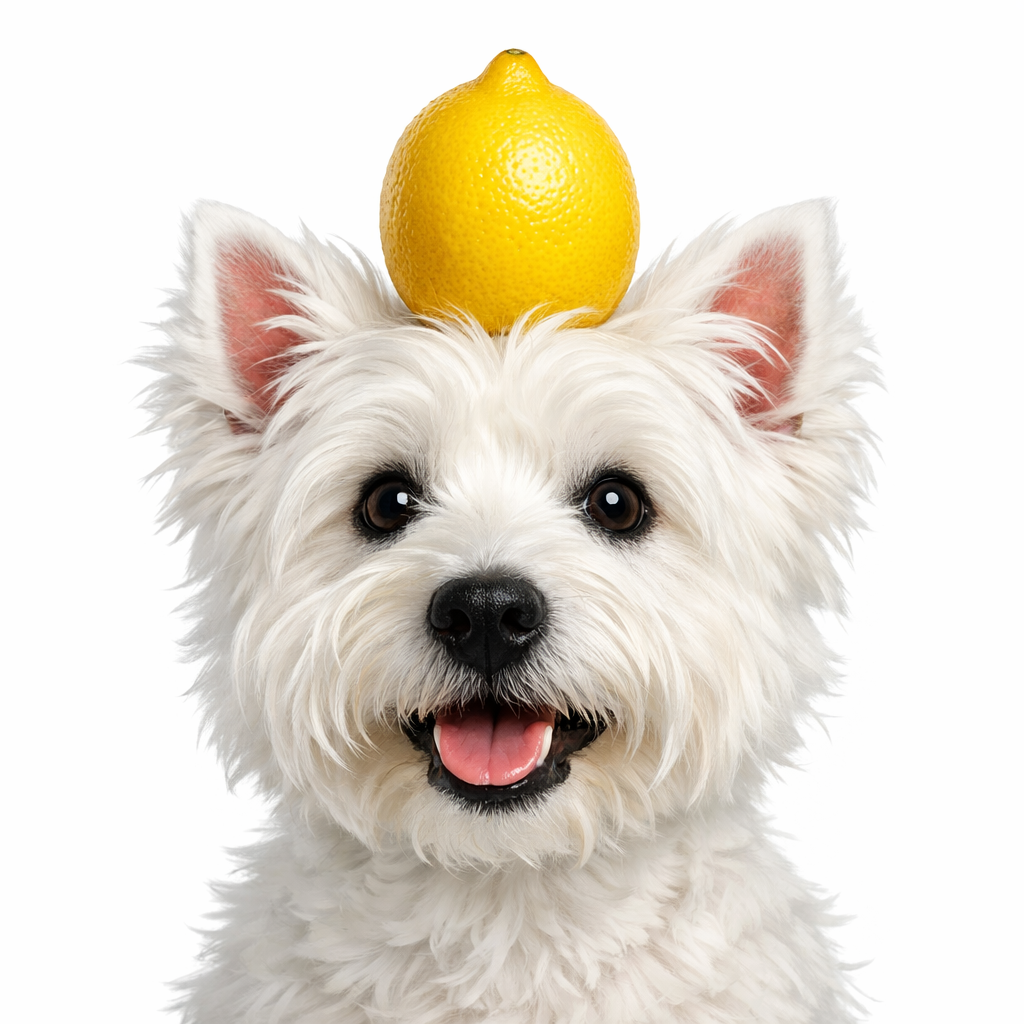

In [2]:
with Image.open(INPUT_IMAGE) as img:
    input_size = img.size

print(f'Reference image dimensions: {input_size[0]} x {input_size[1]}')
display(IPyImage(filename=str(INPUT_IMAGE), width=420))

## 3. 生成同尺寸 RGBA mask

mask 文件必须和输入图同尺寸。本测试把左上偏中区域设置为透明，提示词要求只在透明区域放入一个蓝色玩具球，其余区域保持不变。

Mask saved: outputs/mask_edit/westie_lemon_mask_20260518_131737.png
Transparent edit box: (81, 184, 471, 593)


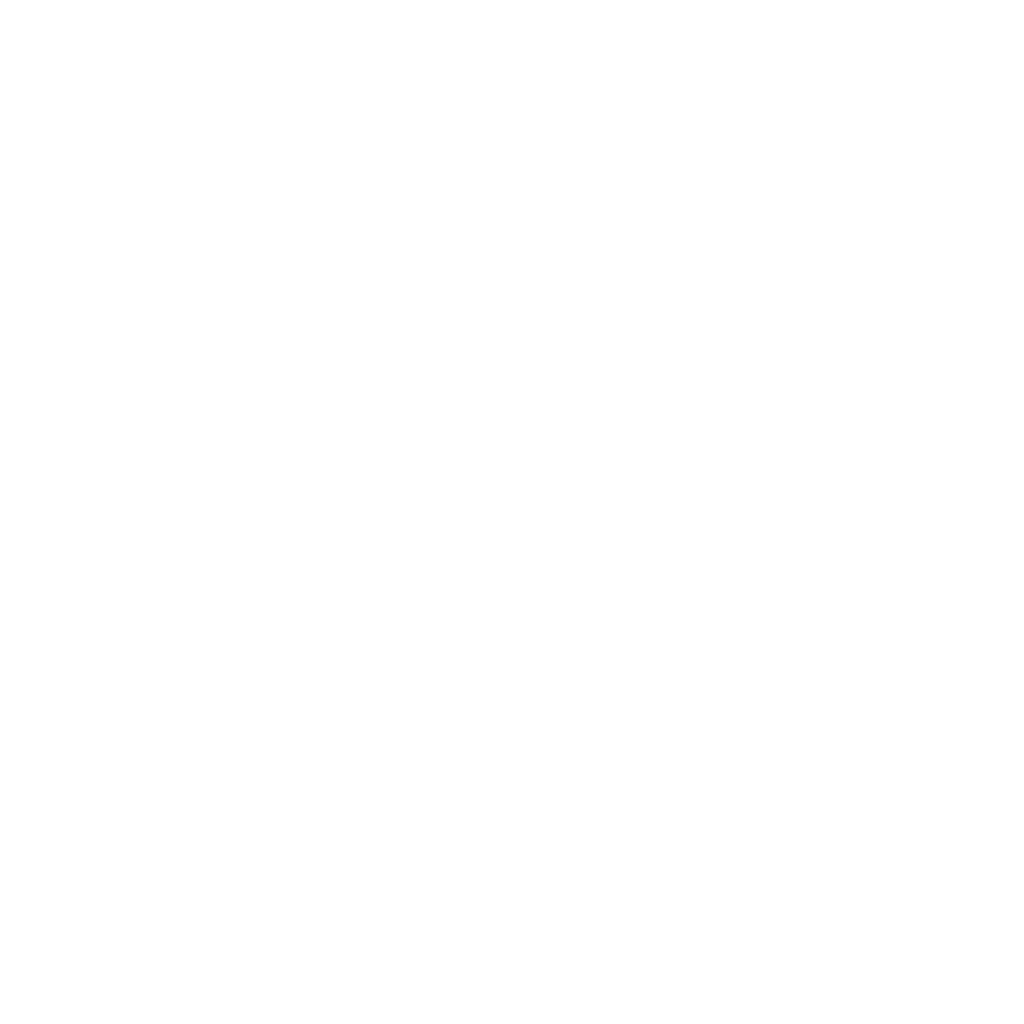

In [3]:
mask_path = OUT_DIR / f'westie_lemon_mask_{STAMP}.png'

with Image.open(INPUT_IMAGE) as source_img:
    width, height = source_img.size

mask = Image.new('RGBA', (width, height), (255, 255, 255, 255))
draw = ImageDraw.Draw(mask)
edit_box = (int(width * 0.08), int(height * 0.18), int(width * 0.46), int(height * 0.58))
draw.rectangle(edit_box, fill=(0, 0, 0, 0))
mask.save(mask_path)

print(f'Mask saved: {mask_path.relative_to(NOTEBOOK_DIR)}')
print(f'Transparent edit box: {edit_box}')
display(IPyImage(filename=str(mask_path), width=420))

## 4. 调用 `images/edits`，上传 `image[]` + `mask`

关键点：multipart 里原图字段仍使用 `image[]`，蒙版字段使用单独的 `mask`。请求体内不传 `model`，因为 Azure 使用 deployment path。

In [4]:
def estimate_cost(usage: dict) -> float:
    if not usage:
        return 0.0
    pricing = {
        'input_text': 5.00,
        'input_image': 8.00,
        'output_image': 30.00,
    }
    input_tokens = usage.get('input_tokens', 0) or 0
    output_tokens = usage.get('output_tokens', 0) or 0
    details = usage.get('input_tokens_details', {}) or {}
    input_text_tokens = details.get('text_tokens', input_tokens) or 0
    input_image_tokens = details.get('image_tokens', 0) or 0
    return (
        input_text_tokens * pricing['input_text'] / 1e6
        + input_image_tokens * pricing['input_image'] / 1e6
        + output_tokens * pricing['output_image'] / 1e6
    )


def call_masked_edit(image_path: Path, mask_file_path: Path):
    url = f'{ENDPOINT}/openai/deployments/{DEPLOYMENT}/images/edits?api-version={API_VERSION}'
    headers = {'api-key': API_KEY}
    data = {
        'prompt': 'Replace only the transparent masked area with a small blue toy ball. Keep everything outside the mask unchanged.',
        'size': '1024x1024',
        'quality': 'low',
        'n': '1',
        'input_fidelity': 'high',
    }
    with image_path.open('rb') as image_file, mask_file_path.open('rb') as mask_file:
        files = [
            ('image[]', (image_path.name, image_file, 'image/png')),
            ('mask', (mask_file_path.name, mask_file, 'image/png')),
        ]
        start = time.time()
        response = requests.post(url, headers=headers, data=data, files=files, timeout=600)
        latency_s = time.time() - start
    return response, latency_s


response, latency_s = call_masked_edit(INPUT_IMAGE, mask_path)
request_id = response.headers.get('apim-request-id', 'N/A')
print(f'HTTP {response.status_code}   latency={latency_s:.2f}s   apim-request-id={request_id}')
print(f'Content-Type: {response.headers.get("content-type", "N/A")}')

if response.status_code != 200:
    print(response.text[:1000])
    raise RuntimeError('Masked edit request failed')

HTTP 200   latency=29.11s   apim-request-id=21d08d07-011a-446f-90fa-53385681c964
Content-Type: application/json


## 5. 保存编辑结果和 JSON 报告

{
  "timestamp": "20260518_131737",
  "endpoint_name": "jzdm-foundry-swn",
  "deployment": "gpt-image-2-globalstandard",
  "api_version": "2025-04-01-preview",
  "http_status": 200,
  "apim_request_id": "21d08d07-011a-446f-90fa-53385681c964",
  "latency_s": 29.11,
  "input_image": "input_images/westie_lemon.png",
  "mask_image": "outputs/mask_edit/westie_lemon_mask_20260518_131737.png",
  "edited_image": "outputs/mask_edit/westie_lemon_mask_edit_20260518_131737.png",
  "returned_size": "1024x1024",
  "returned_quality": "low",
  "usage": {
    "input_tokens": 1051,
    "input_tokens_details": {
      "image_tokens": 1024,
      "text_tokens": 27
    },
    "output_tokens": 196,
    "output_tokens_details": {
      "image_tokens": 196,
      "text_tokens": 0
    },
    "total_tokens": 1247
  },
  "estimated_cost_usd": 0.014207
}


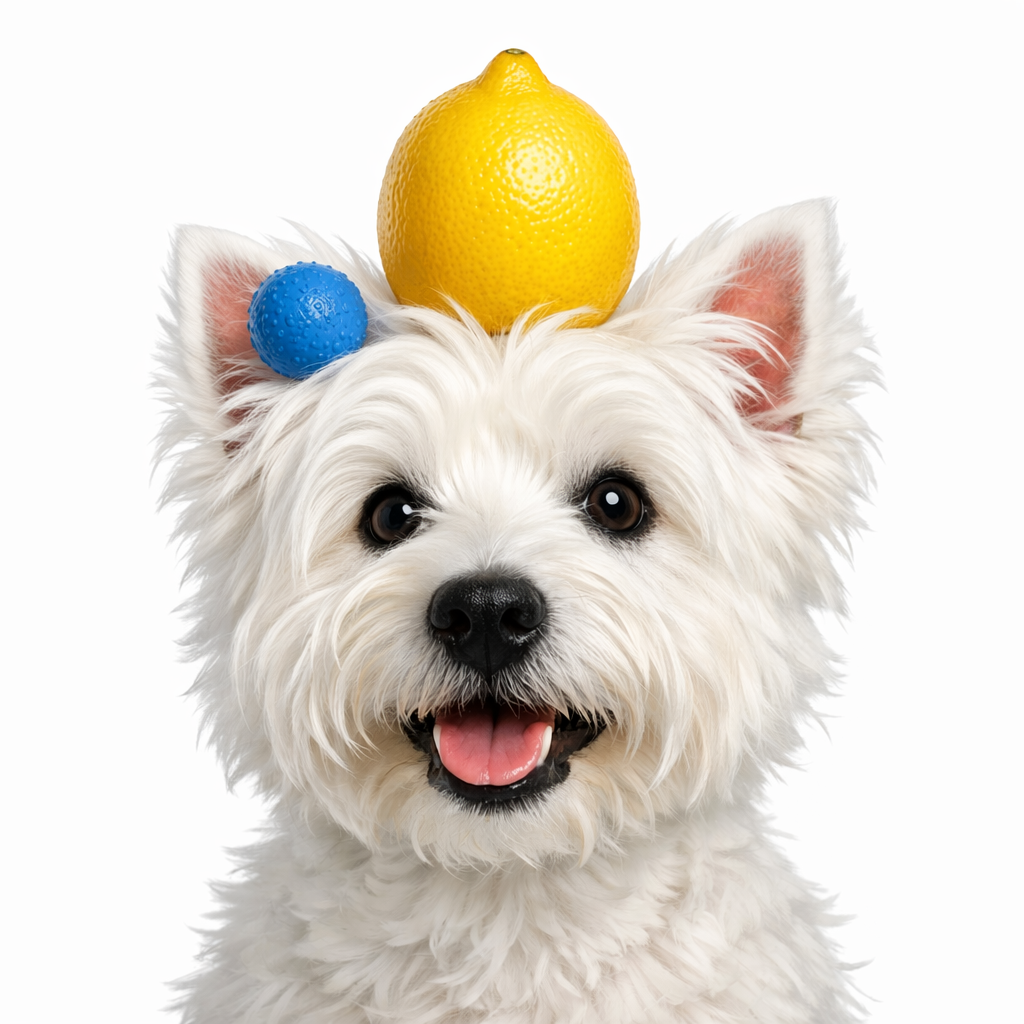

In [5]:
result_json = response.json()
usage = result_json.get('usage', {})
cost = estimate_cost(usage)

edited_image_path = OUT_DIR / f'westie_lemon_mask_edit_{STAMP}.png'
edited_image_path.write_bytes(base64.b64decode(result_json['data'][0]['b64_json']))

report = {
    'timestamp': STAMP,
    'endpoint_name': ENDPOINT_NAME,
    'deployment': DEPLOYMENT,
    'api_version': API_VERSION,
    'http_status': response.status_code,
    'apim_request_id': request_id,
    'latency_s': round(latency_s, 2),
    'input_image': str(INPUT_IMAGE.relative_to(NOTEBOOK_DIR)),
    'mask_image': str(mask_path.relative_to(NOTEBOOK_DIR)),
    'edited_image': str(edited_image_path.relative_to(NOTEBOOK_DIR)),
    'returned_size': result_json.get('size'),
    'returned_quality': result_json.get('quality'),
    'usage': usage,
    'estimated_cost_usd': round(cost, 6),
}
report_path = OUT_DIR / f'mask_edit_report_{STAMP}.json'
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding='utf-8')

print(json.dumps(report, indent=2, ensure_ascii=False))
display(IPyImage(filename=str(edited_image_path), width=420))

## 6. 本次验证结论

只要第 4 节返回 HTTP `200`，即可确认当前 Azure REST 端点接受 `mask` multipart 字段。第 5 节会记录 request id、token usage、估算成本、mask 路径和输出图路径。

面向客户可以这样描述：`gpt-image-2` 的图片编辑支持通过上传与原图同尺寸的 PNG mask 来限定编辑区域，透明区域由模型重绘，不透明区域尽量保持原图。生产使用时建议显式传 `input_fidelity=high`，并保存 `apim-request-id` 便于后续排查。